# **MLIS Practical 06**

**Name:** Yesha Pandya  
**Enrollment No:** 23BT04175  
**Division:** A
**Batch**: C

## **Objective**
To implement route optimization for an IoT-based logistics system using Linear Programming with the `PuLP` library in Python.

## **Theoretical Overview**
In modern IoT-enabled supply chains, sensor telematics (GPS, speed sensors, weather monitors, live traffic updates) stream real-time data from delivery vehicles and roads.

Instead of relying on static distances, the effective cost per route $C_{ij}$ is dynamically adjusted using IoT congestion indices:

$$C_{ij} = \text{Base Distance}_{ij} \times \text{IoT Dynamic Congestion Index}_{ij}$$

Linear Programming (LP) is applied to find the optimal shipping allocations $x_{ij}$ from dynamic supply sources to destinations that minimize total operational cost while meeting demand and supply limits.

## **Mathematical Formulation**

Let:
* $I = \{W_1, W_2, \dots, W_m\}$ be the set of Warehouses (Sources).
* $J = \{D_1, D_2, \dots, D_n\}$ be the set of Distribution Hubs (Destinations).
* $S_i$ = Supply capacity of Warehouse $i \in I$.
* $D_j$ = Product demand at Distribution Hub $j \in J$.
* $c_{ij}$ = Cost of transporting one unit of goods from Warehouse $i$ to Hub $j$.
* $x_{ij}$ = Decision variable representing the number of units transported from $i$ to $j$.

### **I. Objective Function**
Minimize total transportation cost $Z$:
$$\text{Minimize } Z = \sum_{i \in I} \sum_{j \in J} c_{ij} \cdot x_{ij}$$

### **II. Constraints**

* **Supply Constraint:** Total shipments from warehouse $i$ cannot exceed its supply capacity $S_i$:
$$\sum_{j \in J} x_{ij} \le S_i \quad \forall i \in I$$

* **Demand Constraint:** Total shipments received by distribution hub $j$ must satisfy its demand $D_j$:
$$\sum_{i \in I} x_{ij} \ge D_j \quad \forall j \in J$$

* **Non-negativity Constraint:** $$x_{ij} \ge 0 \quad \forall i \in I, j \in J$$

## **Step 1: Setup**

In [ ]:
# Install PuLP package in Google Colab environment
!pip install pulp -q

import pulp
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

print(f"PuLP Version: {pulp.__version__}")
print("Setup completed successfully.")

PuLP Version: 3.3.2
Setup completed successfully.


## **Step 2: Input Data + IoT Telematics Definition**
We define an IoT logistics system with 3 Warehouses ($W_1, W_2, W_3$) and 4 Fulfillment Hubs ($D_1, D_2, D_3, D_4$).

Base distances are dynamically scaled using simulated real-time IoT congestion data.

Dynamic IoT Adjusted Transportation Cost Matrix (₹/Unit):


,D1_Delhi,D2_Bengaluru,D3_Chennai,D4_Kolkata
W1_Mumbai,1582.0,1303.4,1675.8,2371.6
W2_Pune,1522.5,882.0,1173.0,2340.0
W3_Ahmedabad,1149.5,1850.0,1737.2,2157.4


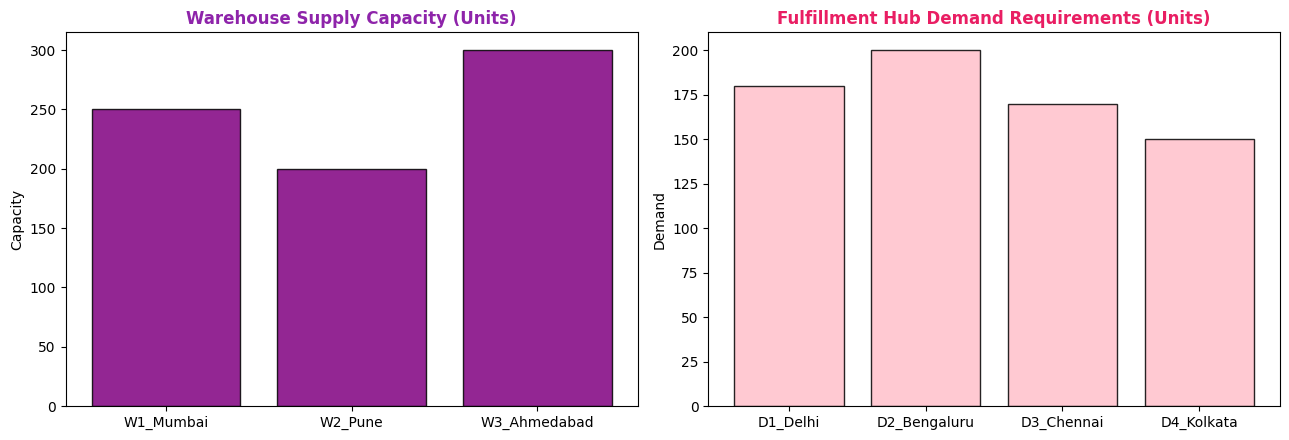

In [ ]:
# Define sources, destinations, and capacities
warehouses = ['W1_Mumbai', 'W2_Pune', 'W3_Ahmedabad']
destinations = ['D1_Delhi', 'D2_Bengaluru', 'D3_Chennai', 'D4_Kolkata']

supply = {
    'W1_Mumbai': 250,
    'W2_Pune': 200,
    'W3_Ahmedabad': 300
}

demand = {
    'D1_Delhi': 180,
    'D2_Bengaluru': 200,
    'D3_Chennai': 170,
    'D4_Kolkata': 150
}

# Base distances (in km)
base_distance = {
    'W1_Mumbai':    {'D1_Delhi': 1400, 'D2_Bengaluru': 980,  'D3_Chennai': 1330, 'D4_Kolkata': 1960},
    'W2_Pune':      {'D1_Delhi': 1450, 'D2_Bengaluru': 840,  'D3_Chennai': 1150, 'D4_Kolkata': 1800},
    'W3_Ahmedabad': {'D1_Delhi': 950,  'D2_Bengaluru': 1480, 'D3_Chennai': 1720, 'D4_Kolkata': 1610}
}

# Simulated IoT dynamic congestion multiplier (Telemetry stream)
np.random.seed(42)
iot_congestion = {
    w: {d: round(np.random.uniform(1.0, 1.35), 2) for d in destinations}
    for w in warehouses
}

# Calculate effective dynamic cost matrix
dynamic_cost = {
    w: {d: round(base_distance[w][d] * iot_congestion[w][d], 2) for d in destinations}
    for w in warehouses
}

# Display dynamic cost matrix as DataFrame
df_cost = pd.DataFrame(dynamic_cost).T
print("Dynamic IoT Adjusted Transportation Cost Matrix (₹/Unit):")
display(df_cost)

# Plot Supply v/s Demand Comparison
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(supply.keys(), supply.values(), color="purple", alpha=0.85, edgecolor="black")
ax[0].set_title("Warehouse Supply Capacity (Units)", fontsize=12, fontweight='bold', color="#8E24AA")
ax[0].set_ylabel("Capacity")

ax[1].bar(demand.keys(), demand.values(), color='pink', alpha=0.85, edgecolor="black")
ax[1].set_title("Fulfillment Hub Demand Requirements (Units)", fontsize=12, fontweight='bold', color="#E91E63")
ax[1].set_ylabel("Demand")

plt.tight_layout()
plt.show()

## **Step 3: Visualize the unoptimized IoT logistics network**

Before running the optimization model, we'll construct a bipartite graph representing all active dynamic links and dynamic cost weights.

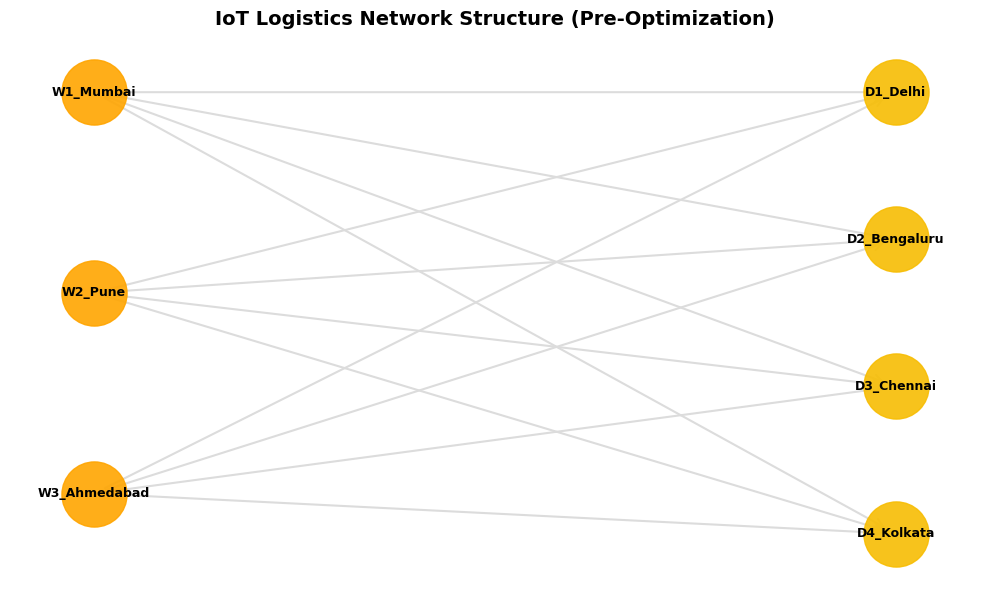

In [ ]:
# Create bipartite network graph
G = nx.DiGraph()

for w in warehouses:
    G.add_node(w, bipartite=0)
for d in destinations:
    G.add_node(d, bipartite=1)

for w in warehouses:
    for d in destinations:
        G.add_edge(w, d, weight=dynamic_cost[w][d])

pos = {}
pos.update((node, (1, -i * 1.5)) for i, node in enumerate(warehouses))
pos.update((node, (2, -i * 1.1)) for i, node in enumerate(destinations))

plt.figure(figsize=(10, 6))

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=warehouses, node_color="orange", node_size=2200, alpha=0.9)
nx.draw_networkx_nodes(G, pos, nodelist=destinations, node_color="#F7BD03", node_size=2200, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gainsboro', width=1.5, arrowstyle='->', arrowsize=15)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_color='black', font_weight='bold', font_size=9)

plt.title("IoT Logistics Network Structure (Pre-Optimization)", fontsize=14, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

## **Step 4: Linear Programming Model Formulation using PuLP**

We'll instantiate the PuLP model $→$ add continuous decision variables $x_{ij} \ge 0$ $→$ define the cost-minimization objective function $→$ append supply and demand constraints.

In [ ]:
# Initialize Optimization Model
model = pulp.LpProblem("IoT_Route_Optimization", pulp.LpMinimize)

# Decision Variables: x[w, d] = units transported from warehouse w to destination d
route_vars = pulp.LpVariable.dicts("Route", (warehouses, destinations), lowBound=0, cat='Continuous')

# Objective Function: Minimize total dynamic cost
model += pulp.lpSum([route_vars[w][d] * dynamic_cost[w][d] for w in warehouses for d in destinations]), "Total_Transportation_Cost"

# Supply Constraints
for w in warehouses:
    model += pulp.lpSum([route_vars[w][d] for d in destinations]) <= supply[w], f"Supply_Constraint_{w}"

# Demand Constraints
for d in destinations:
    model += pulp.lpSum([route_vars[w][d] for w in warehouses]) >= demand[d], f"Demand_Constraint_{d}"

# Solve Model
solver = pulp.PULP_CBC_CMD(msg=False)
model.solve(solver)

print(f"Model Optimization Status: {pulp.LpStatus[model.status]}")
print(f"Minimum Total Transportation Cost: ₹{pulp.value(model.objective):,.2f}")

Model Optimization Status: Optimal
Minimum Total Transportation Cost: ₹984,394.00


## **Step 5: Optimization Solution Analysis + Results Table**

Extract active route allocations from the solved model and compute utilization metrics.


Optimal Unit Allocation Matrix (x_ij):



,D1_Delhi,D2_Bengaluru,D3_Chennai,D4_Kolkata
W1_Mumbai,0.0,170.0,0.0,30.0
W2_Pune,0.0,30.0,170.0,0.0
W3_Ahmedabad,180.0,0.0,0.0,120.0


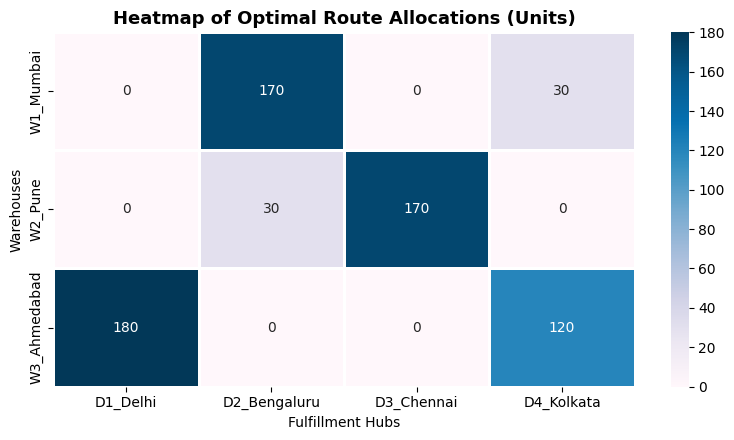

In [ ]:
# Extract optimal shipments
results_matrix = []

for w in warehouses:
    row = []
    for d in destinations:
        val = route_vars[w][d].varValue
        row.append(val if val is not None else 0.0)
    results_matrix.append(row)

df_results = pd.DataFrame(results_matrix, index=warehouses, columns=destinations)

print("\nOptimal Unit Allocation Matrix (x_ij):\n")
display(df_results)

# Plot Heatmap of Optimal Unit Allocation
plt.figure(figsize=(8, 4.5))
sns.heatmap(df_results, annot=True, fmt=".0f", cmap="PuBu", cbar=True, linewidths=1, linecolor='white')
plt.title("Heatmap of Optimal Route Allocations (Units)", fontsize=13, fontweight='bold')
plt.ylabel("Warehouses")
plt.xlabel("Fulfillment Hubs")
plt.tight_layout()
plt.show()

## **Step 6: Optimal Logistics Network Visual Map**

Visualize the finalized routing decisions.

*[highlighted active shipping routes in pink/purple and zero-shipment unused paths in muted grey]*

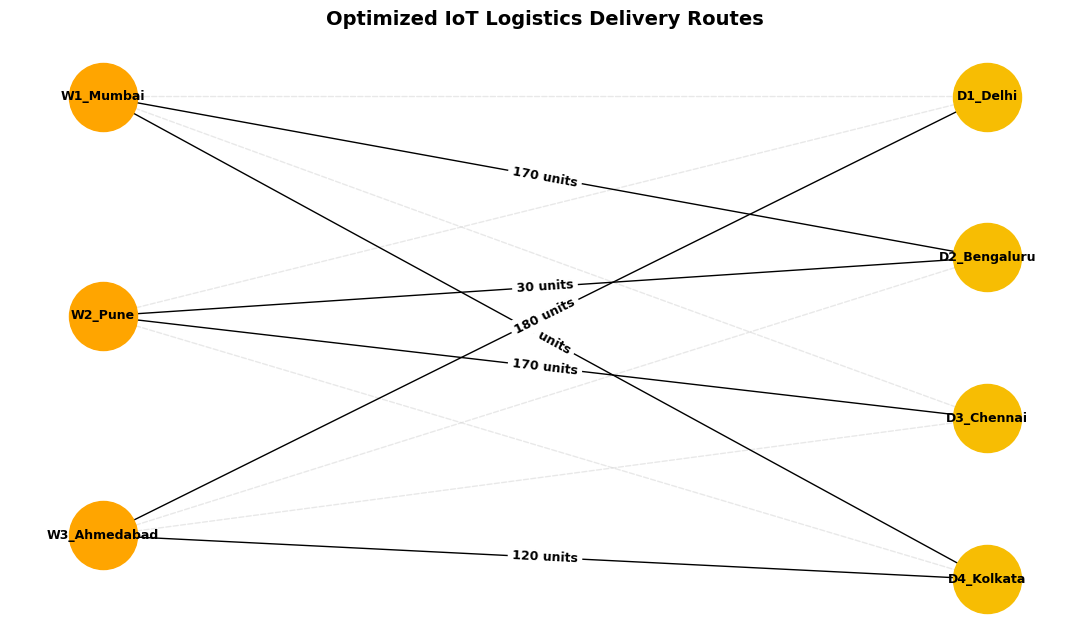

In [ ]:
plt.figure(figsize=(11, 6.5))

# Draw base nodes
nx.draw_networkx_nodes(G, pos, nodelist=warehouses, node_color="orange", node_size=2400)
nx.draw_networkx_nodes(G, pos, nodelist=destinations, node_color="#F7BD03", node_size=2400)
nx.draw_networkx_labels(G, pos, font_color='black', font_weight='bold', font_size=9)

# Categorize active vs inactive edges
active_edges = [(w, d) for w in warehouses for d in destinations if df_results.loc[w, d] > 0]
inactive_edges = [(w, d) for w in warehouses for d in destinations if df_results.loc[w, d] == 0]

# Draw inactive edges
nx.draw_networkx_edges(G, pos, edgelist=inactive_edges, edge_color='lightgrey', width=1, style='dashed', alpha=0.5)

# Draw active edges with width proportional to volume
nx.draw_networkx_edges(G, pos, edgelist=active_edges, edge_color="black", arrowstyle='->')

# Add edge labels for active units
edge_labels = {(w, d): f"{int(df_results.loc[w, d])} units" for w, d in active_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="black", font_weight='bold', font_size=9)

plt.title("Optimized IoT Logistics Delivery Routes", fontsize=14, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

## **Conclusion**
In this practical, an end-to-end route optimization model for an IoT-enabled logistics system was successfully designed and executed using Linear Programming with Python's PuLP library.
1. Formulated decision variables, linear objective functions, and capacity constraints programmatically.
2. Integrated IoT dynamic congestion updates into the route cost matrix.
3. Solved the LP problem using the CBC solver and verified that all demand and supply constraints were strictly met.
4. Visualized node connections and optimized flow paths cleanly using Matplotlib, Seaborn, and NetworkX in a unified palette.